In [1]:
%cd plot/

[Errno 2] No such file or directory: 'plot/'
/opt/hpcaas/.mounts/fs-0df31b178aa4037ac/home/zhaobc/scientist/plot


/home/zhaobc/miniconda3/envs/nanogpt-record-1-11/lib/python3.12/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [2]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
# from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
# from parse_levels import process_metrics, human_train_time_dict, convert_to_dict, compute_gap_in_percentage, compute_gap_in_percentage_list, convert_to_dict_multiple_runs
# from parse_levels import filter_folder_info
import pandas as pd
import matplotlib.ticker as ticker
from plot_utils import plot_gap_comparison
import re
import copy
import json

In [3]:
import importlib
import parse_levels
importlib.reload(parse_levels)
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
from parse_levels import process_metrics, human_train_time_dict, convert_to_dict, compute_gap_in_percentage, compute_gap_in_percentage_list, convert_to_dict_multiple_runs
from parse_levels import filter_folder_info


In [4]:
# for each item in the dict, if any two have the same 'record', remove the one with lower number of steps in metric
# def deduplicate_metrics(search_results):
#     records_length_so_far = {}
#     new_search_results = {}
#     for key, value in search_results.items():
#         if value['record'] not in records_length_so_far:
#             records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
#             new_search_results[key] = value
#         else:
#             if len(value['metrics']['step']) > records_length_so_far[value['record']][0]:
#                 new_search_results.pop(records_length_so_far[value['record']][1])

#                 records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
#                 new_search_results[key] = value
#     return new_search_results



In [5]:
# ori_results = find_levels_in_configs_glob(
#     [
#         '/checkpoint/maui/zhaobc/scientist/workspace/record_*',
#     ]
# )
# with open('/checkpoint/maui/zhaobc/scientist/code_analysis_with_all_versions_knowledge_o3_mini.json', 'r') as f:
#     o3_results = json.load(f)


In [6]:
# with open('may8.cache', 'w') as f:
#     json.dump(ori_results, f)

In [7]:
with open('/home/zhaobc/scientist/plot/may13.cache', 'r') as f:
    ori_results = json.load(f)

In [8]:
# z_folder_info = filter_folder_info(ori_results, [('levels', 'z')])
unique_levels = set()
for key, value in ori_results.items():
    unique_levels.add(value['levels'][0])
unique_levels

{1, 12, 125, 129, 19, 2, 5, 'z'}

In [9]:
# 1 is psuedo-code
# 2 is text description
# 5 is paper like 
# 9 is adhoc knowledge, we can ignore it for now
# 'z' is zero knowledge

In [10]:
folder_info = ori_results
# o3_results

In [11]:
len(folder_info)

3592

In [12]:
# flat search -- n_initial_hypotheses = 50
flat_params = [
    ('runner', 'bon'),
    # ('n_initial_hypotheses', 50),
    ('n_iterations', 1),
]
# tree search -- n_initial_hypotheses = 1, n_hypotheses = 3
tree_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 1),
    ('n_hypotheses', 3),
]
# forest search -- n_initial_hypotheses = 3, n_hypotheses = 3
forest_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
]
# AIDE -- n_initial_hypotheses = 3, n_hypotheses = 1, debug_prob = 0.5
aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 1),
    ('debug_prob', 0.5),
]
# MultiAIDE -- n_initial_hypotheses = 3, n_hypotheses = 3, debug_prob = 0.5
multi_aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
    ('debug_prob', 0.5),
]

search_algo_params = {
    'flat': flat_params,
    'tree': tree_params,
    'forest': forest_params,
    'ori_aide': aide_params,
    'multi_aide': multi_aide_params,
}

plot_info = {}

for search_algo, params in search_algo_params.items():
    plot_info[search_algo] = {}
    for level in ['z', 1, 2, 5, 12, 125]:
        plot_info[search_algo][level] = {}
        for model in ['deepseek-r1', 'o3-mini']:
        # for model in ['o3-mini']:
            search_params = params + [('levels', level), ('model', model)]
            filtered_folder_info = filter_folder_info(folder_info, search_params)
            print(f'{search_algo} {level} {model} {len(filtered_folder_info)}')
            plot_info[search_algo][level][model] = filtered_folder_info



flat z deepseek-r1 20
flat z o3-mini 60
flat 1 deepseek-r1 31
flat 1 o3-mini 99
flat 2 deepseek-r1 20
flat 2 o3-mini 60
flat 5 deepseek-r1 60
flat 5 o3-mini 60
flat 12 deepseek-r1 71
flat 12 o3-mini 64
flat 125 deepseek-r1 75
flat 125 o3-mini 55
tree z deepseek-r1 20
tree z o3-mini 60
tree 1 deepseek-r1 18
tree 1 o3-mini 106
tree 2 deepseek-r1 20
tree 2 o3-mini 60
tree 5 deepseek-r1 60
tree 5 o3-mini 60
tree 12 deepseek-r1 58
tree 12 o3-mini 51
tree 125 deepseek-r1 75
tree 125 o3-mini 74
forest z deepseek-r1 20
forest z o3-mini 60
forest 1 deepseek-r1 18
forest 1 o3-mini 106
forest 2 deepseek-r1 20
forest 2 o3-mini 60
forest 5 deepseek-r1 60
forest 5 o3-mini 60
forest 12 deepseek-r1 55
forest 12 o3-mini 64
forest 125 deepseek-r1 90
forest 125 o3-mini 70
ori_aide z deepseek-r1 20
ori_aide z o3-mini 60
ori_aide 1 deepseek-r1 15
ori_aide 1 o3-mini 106
ori_aide 2 deepseek-r1 20
ori_aide 2 o3-mini 60
ori_aide 5 deepseek-r1 57
ori_aide 5 o3-mini 57
ori_aide 12 deepseek-r1 54
ori_aide 12 o3-m

In [13]:
from tqdm import tqdm

figure_data = {}
for search_algo in search_algo_params.keys():
    for level in ['z', 1, 2, 5, 12, 125]:
        # for model in ['o3-mini']:
        for model in ['deepseek-r1', 'o3-mini']:
            # plot_info[search_algo][level][model] = deduplicate_metrics(plot_info[search_algo][level][model])
            try:
                plot_info[search_algo][level][model] = process_metrics(plot_info[search_algo][level][model])
                figure_data[f'{search_algo}_{level}_{model}'] = convert_to_dict_multiple_runs(plot_info[search_algo][level][model], keep_name=True)
            except FileNotFoundError as e:
                print(f"FileNotFoundError for {search_algo}, level {level}, model {model}: {e}")


In [14]:
human_train_time_dict = {
    1: 2968348,
    2: 2209926,
    3: 1386147,
    4: 1301740,
    5: 949528,
    6: 766259,
    7: 773072,
    8: 662205,
    9: 505531,
    10: 477150,
    11: 442985,
    12: 317839,
    13: 289805,
    14: 273107,
    15: 241463,
    16: 232971,
    17: 220374,
    18: 211840,
    19: 199442,
    20: 188680,
    21: 184262
}


In [15]:
figure_data_percent = {}
for key in figure_data.keys():
    print(key)
    figure_data_percent[key] = compute_gap_in_percentage_list(figure_data[key], human_train_time_dict, keep_name=True)
    figure_data_percent[key] = {str(k): v for k, v in figure_data_percent[key].items()}
    try:
        del figure_data_percent[key]['6']
    except:
        pass

flat_z_deepseek-r1
flat_z_o3-mini
flat_1_deepseek-r1
flat_1_o3-mini
flat_2_deepseek-r1
flat_2_o3-mini
flat_5_deepseek-r1
flat_5_o3-mini
flat_12_deepseek-r1
flat_12_o3-mini
flat_125_deepseek-r1
flat_125_o3-mini
tree_z_deepseek-r1
tree_z_o3-mini
tree_1_deepseek-r1
tree_1_o3-mini
tree_2_deepseek-r1
tree_2_o3-mini
tree_5_deepseek-r1
tree_5_o3-mini
tree_12_deepseek-r1
tree_12_o3-mini
tree_125_deepseek-r1
tree_125_o3-mini
forest_z_deepseek-r1
forest_z_o3-mini
forest_1_deepseek-r1
forest_1_o3-mini
forest_2_deepseek-r1
forest_2_o3-mini
forest_5_deepseek-r1
forest_5_o3-mini
forest_12_deepseek-r1
forest_12_o3-mini
forest_125_deepseek-r1
forest_125_o3-mini
ori_aide_z_deepseek-r1
ori_aide_z_o3-mini
ori_aide_1_deepseek-r1
ori_aide_1_o3-mini
ori_aide_2_deepseek-r1
ori_aide_2_o3-mini
ori_aide_5_deepseek-r1
ori_aide_5_o3-mini
ori_aide_12_deepseek-r1
ori_aide_12_o3-mini
ori_aide_125_deepseek-r1
ori_aide_125_o3-mini
multi_aide_z_deepseek-r1
multi_aide_z_o3-mini
multi_aide_1_deepseek-r1
multi_aide_1_o3-m

In [16]:
# Get top 3 values for each experiment, padding if needed
def get_top_3_values(arr, config=None, exp_name=None):
    if len(arr) == 0:
        return np.array([0, 0, 0])
    # Filter out values > 3 or < 0
    valid_arr = []
    for x in arr:
        if not (0 <= x <= 3):
            print(f"Warning: Value {x} from {config} {exp_name} outside valid range [0,3], replacing with 0")
            valid_arr.append(0)
        else:
            valid_arr.append(x)
    sorted_arr = np.sort(valid_arr)[::-1] # Sort descending
    if len(arr) >= 3:
        return sorted_arr[:3]
    else:
        # Pad with repeats of max value to get 3 numbers
        padding = 3 - len(arr)
        if not ('r1' in config):
            # Only log warning once per config
            if exp_name == list(figure_data_percent[config].keys())[0]:
                print(f"Warning: Config {config} has experiments with fewer than 3 values, padding with {padding} repeated values")
        return np.concatenate([sorted_arr, np.repeat(sorted_arr[-1], padding)])

# Process each config
results_by_config = {}
for config, experiments in figure_data_percent.items():
    # Get top 3 values for each experiment
    top3_by_experiment = {}
    if len(experiments) == 0:
        print(f'Warning: {config} has no experiments')
    for exp_name, values in experiments.items():
        top3 = get_top_3_values(values, config, exp_name)
        top3_by_experiment[exp_name] = top3
    
    # Average across experiments for each of the 3 positions
    all_exp_values = np.array(list(top3_by_experiment.values()))
    mean_values = np.mean(all_exp_values, axis=0) # Shape (3,)
    
    # Calculate standard error of the mean (SEM) instead of std
    n = len(all_exp_values) if len(all_exp_values) > 0 else 1
    sem_value = np.std(mean_values) / np.sqrt(n)
    
    results_by_config[config] = {
        'means': np.mean(mean_values) if len(all_exp_values) > 0 else 0,
        'std': sem_value if len(all_exp_values) > 0 else 0  # Using 'std' key for compatibility but storing SEM
    }


In [17]:
results_by_config['ori_aide_1_deepseek-r1']

{'means': 0.17269570584189253, 'std': 0.0}

In [18]:
top3_by_experiment.keys()

dict_keys(['8', '14', '18', '13', '4', '19', '11', '2', '7', '17', '10', '3', '12', '1', '15', '5', '16', '9'])

In [19]:
figure_data_percent['ori_aide_1_deepseek-r1']

{'9': array([17.7997604]),
 '14': array([0.]),
 '8': array([4.2248682]),
 '16': array([0.]),
 '13': array([0.]),
 '11': array([0.]),
 '4': array([0.68158098]),
 '18': array([7.12889176]),
 '10': array([0.]),
 '15': array([0.48539802]),
 '7': array([0.]),
 '5': array([0.99460902]),
 '12': array([0.]),
 '17': array([0.25615186])}

In [20]:
import matplotlib as mpl

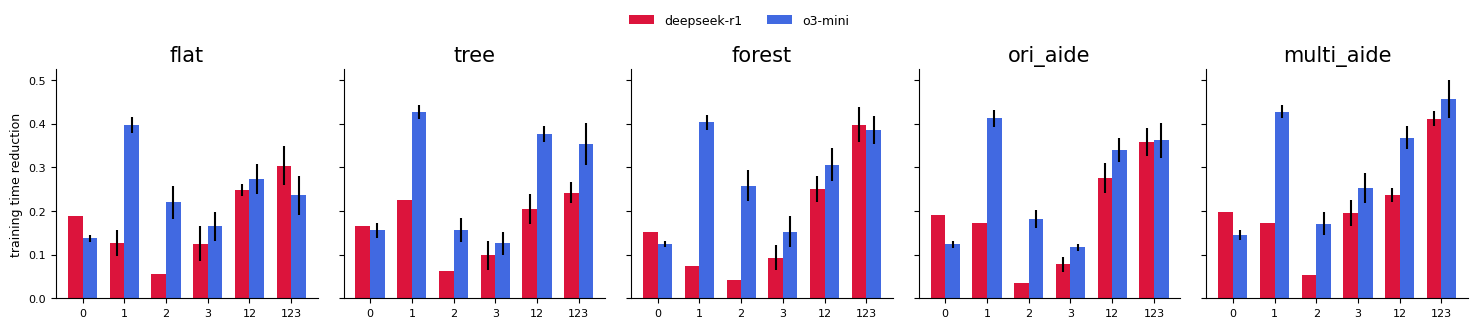

In [21]:
colors = ['crimson', 'royalblue']
colors = ['crimson', 'royalblue', 'gold', 'forestgreen', 'purple']
# colors = [plt.cm.get_cmap('plasma')(level) for level in [0.3, 0.9]]
# x_labels = ['z', 1, 2, 5, 12, 125]
x_labels = [0, 1, 2, 3, 12, 123]
x_values = np.arange(len(x_labels))
fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
w = 0.35

for idx, search_algo in enumerate(['flat', 'tree', 'forest', 'ori_aide', 'multi_aide']):
    for i, model in enumerate(['deepseek-r1', 'o3-mini']):
        y = []
        err = []
        for level in ['z', 1, 2, 5, 12, 125]:
            key = f'{search_algo}_{level}_{model}'
            if key in results_by_config:
                y.append(results_by_config[key]['means'])
                err.append(results_by_config[key]['std'])
            else:
                y.append(0)
                err.append(0)
        axes[idx].bar(x_values - w/2 + i * w, y, width=w, color=colors[i], label=model if idx == 0 else "", yerr=err)
    
    axes[idx].set_title(search_algo, fontsize=15)
    axes[idx].set_xticks(x_values)
    axes[idx].set_xticklabels(x_labels, fontsize=8)
    axes[idx].tick_params(axis='y', labelsize=8)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)
    if idx == 0:
        axes[idx].set_ylabel('training time reduction', fontsize=9)

# shared legend above all plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=9, frameon=False, bbox_to_anchor=(0.5, 1.12))

fig.tight_layout(rect=[0, 0, 1, 1.05])
plt.show()

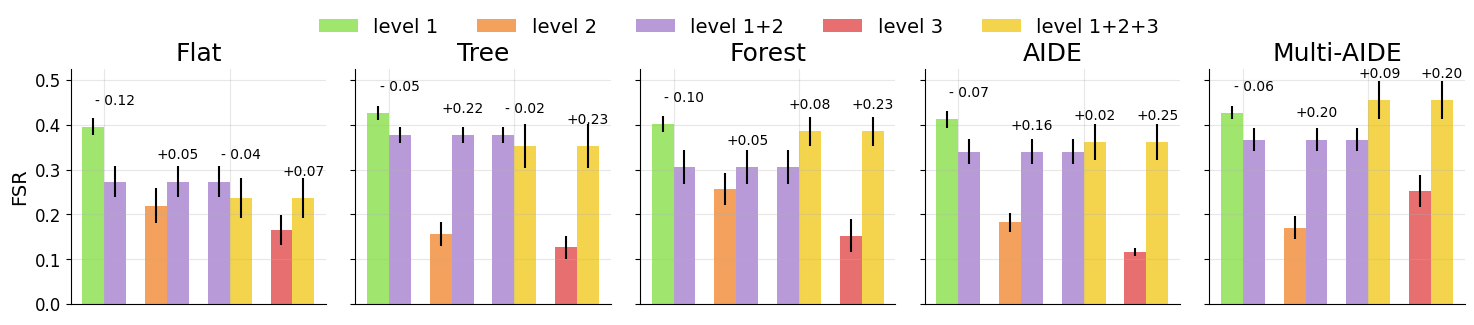

In [24]:
# colors = ['magma', 'plasma']
# colors = ['crimson', 'royalblue', 'gold', 'forestgreen', 'purple']
# earthy_colors = ['brown', 'lightsalmon', 'olive', 'maroon', 'forestgreen']
colors = ['#A0E56D', '#F3A15D', '#E76F6F', '#B99AD9', '#F4D44D']
color_mapping = {1: colors[0], 2: colors[1], 5: colors[2], 12: colors[3], 125: colors[4]}
x_labels = ['1 vs 1+2', '2 vs 1+2', '1+2 vs 1+2+3', '3 vs 1+2+3']
x_values = np.arange(len(x_labels))
fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
w = 0.35

for idx, search_algo in enumerate(['flat', 'tree', 'forest', 'ori_aide', 'multi_aide']):
    z = []
    for i, level in enumerate([1, 12]):
        y = []
        err = []
        key = f'{search_algo}_{level}_o3-mini'
        if key in results_by_config:
            y.append(results_by_config[key]['means'])
            z.append(results_by_config[key]['means'])
            err.append(results_by_config[key]['std'])
        else:
            y.append(0)
            z.append(0)
            err.append(0)
        axes[idx].bar(x_values[0:1] - w/2 + i * w, y, width=w, color=color_mapping[level], label=level if idx == 0 else "", yerr=err)
        if len(z) == 2:
            diff = z[1] - z[0]
            sign = '+' if diff > 0 else '- '
            axes[idx].text(x_values[0] - w/2 + i * w, max(z) + 0.05, f'{sign}{abs(diff):.2f}', ha='center', fontsize=10)

    z = []
    for i, level in enumerate([2, 12]):
        y = []
        err = []
        key = f'{search_algo}_{level}_o3-mini'
        if key in results_by_config:
            y.append(results_by_config[key]['means'])
            z.append(results_by_config[key]['means'])
            err.append(results_by_config[key]['std'])
        else:
            y.append(0)
            z.append(0)
            err.append(0)
        axes[idx].bar(x_values[1:2] - w/2 + i * w, y, width=w, color=color_mapping[level], label=level if idx == 0 else "", yerr=err)
        if len(z) == 2:
            diff = z[1] - z[0]
            sign = '+' if diff > 0 else '- '
            axes[idx].text(x_values[1] - w/2 + i * w, max(z) + 0.05, f'{sign}{abs(diff):.2f}', ha='center', fontsize=10)

    z = []
    for i, level in enumerate([12, 125]):
        y = []
        err = []
        key = f'{search_algo}_{level}_o3-mini'
        if key in results_by_config:
            y.append(results_by_config[key]['means'])
            z.append(results_by_config[key]['means'])
            err.append(results_by_config[key]['std'])
        else:
            y.append(0)
            z.append(0)
            err.append(0)
        axes[idx].bar(x_values[2:3] - w/2 + i * w, y, width=w, color=color_mapping[level], label=level if idx == 0 else "", yerr=err)
        if len(z) == 2:
            diff = z[1] - z[0]
            sign = '+' if diff > 0 else '- '
            axes[idx].text(x_values[2] - w/2 + i * w, max(z) + 0.05, f'{sign}{abs(diff):.2f}', ha='center', fontsize=10)

    z = []
    for i, level in enumerate([5, 125]):
        y = []
        err = []
        key = f'{search_algo}_{level}_o3-mini'
        if key in results_by_config:
            y.append(results_by_config[key]['means'])
            z.append(results_by_config[key]['means'])
            err.append(results_by_config[key]['std'])
        else:
            y.append(0)
            z.append(0)
            err.append(0)
        axes[idx].bar(x_values[3:4] - w/2 + i * w, y, width=w, color=color_mapping[level], label=level if idx == 0 else "", yerr=err)
        if len(z) == 2:
            diff = z[1] - z[0]
            sign = '+' if diff > 0 else '- ' 
            axes[idx].text(x_values[3] - w/2 + i * w, max(z) + 0.05, f'{sign}{abs(diff):.2f}', ha='center', fontsize=10)
    
    search_algo_mapping = {
        'flat': 'Flat',
        'tree': 'Tree',
        'forest': 'Forest',
        'ori_aide': 'AIDE',
        'multi_aide': 'Multi-AIDE'
    }
    axes[idx].set_title(search_algo_mapping[search_algo], fontsize=18)
    axes[idx].tick_params(axis='x', length=0)
    axes[idx].set_xticklabels([])
    axes[idx].tick_params(axis='y', labelsize=12)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)
    axes[idx].grid(True, alpha=0.3)
    if idx == 0:
        axes[idx].set_ylabel('FSR', fontsize=14)

# shared legend above all plots
handles, labels = axes[0].get_legend_handles_labels()
handles = [h for i, h in enumerate(handles) if i not in [1, 4, 5]]
# labels = [l for i, l in enumerate(labels) if i not in [1, 4, 5]]
labels = ['level 1', 'level 2', 'level 1+2', 'level 3', 'level 1+2+3']
fig.legend(handles, labels, loc='upper center', ncol=5, fontsize=14, frameon=False, bbox_to_anchor=(0.5, 1.12))

fig.tight_layout(rect=[0, 0, 1, 1.05])
plt.savefig('figures/comp_hint_fsr.pdf', dpi=200, bbox_inches='tight')

In [23]:
len(handles)

5